In [1]:
!python3 -m pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.6 MB 2.2 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/9.6 MB 2.5 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.6 MB 2.2 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.6 MB 2.1 MB/s eta 0:00:04
   ---------- ----------------------------- 2.6/9.6 MB 2.2 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/9.6 MB 2.2 MB/s eta 0:00:04
   -------------- ------------------------- 3.4/9.6 MB 2.1 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.6 MB 2.1 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.6 MB 2.2 MB/s eta 0:00:03
   ------------------- -------------------- 4.7/9.6 MB 2.2 MB/s eta 0:00:03
   ---------------------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\trakh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import glob
import os

# Folder containing the 20 CSV files
data_path = "true_emp"

# Automatically find all .csv files in folder
csv_files = sorted(glob.glob(os.path.join(data_path, "*.csv")))

# Prepare an empty list to collect sub-dataframes
all_dfs = []

# Loop through all files and read them one by one
for i, file in enumerate(csv_files, start=1):
    # Derive model name from filename (optional)
    # e.g., "LLM_FLARE_trial1.csv" → "LLM_FLARE_trial1"
    # model_name = os.path.splitext(os.path.basename(file))[0]
    
    # Read inventory values (assumed one per line, 50 values total)
    data = pd.read_csv(file, header=None, names=["inventory_size"])
    
    # Assign crafting step numbers (1–50)
    data["step"] = range(1, len(data) + 1)
    
    # Assign model and trial identifiers
    data["model"] = "true_emp"
    data["trial"] = i  # could also use filename patterns instead
    
    # Append to main DataFrame list
    all_dfs.append(data)

# Combine into one master DataFrame
df = pd.concat(all_dfs, ignore_index=True)

# Optional rearrangement of columns to match schema
df = df[["model", "trial", "step", "inventory_size"]]

print(df.head())
print(df.shape)  # should show (20 * 50) rows total = 1000

# Save combined data if needed
df.to_csv(f"combined_inventory_data\combined_inventory_data_true_emp_50iters_20trials.csv", index=False)


      model  trial  step  inventory_size
0  true_emp      1     1  inventory_size
1  true_emp      1     2               5
2  true_emp      1     3               6
3  true_emp      1     4               7
4  true_emp      1     5               8
(1020, 4)


<>:43: SyntaxWarning: invalid escape sequence '\c'
<>:43: SyntaxWarning: invalid escape sequence '\c'
C:\Users\trakh\AppData\Local\Temp\ipykernel_31976\3636378777.py:43: SyntaxWarning: invalid escape sequence '\c'
  df.to_csv(f"combined_inventory_data\combined_inventory_data_{data_path}_50iters_20trials.csv", index=False)


In [ ]:
import os
import json
import pandas as pd

# Define base directory where trial files are located
base_dir = "trail_20_with_fallback\with"  # adjust to where your trial_*.json/.jsonl files are stored

# Prepare an empty list to collect all DataFrames
all_trials = []

# Loop through all trial summary files
for trial_num in range(1, 21):  # as    suming 20 trials total
    summary_path = os.path.join(base_dir, f"trial_{trial_num}_summary.json")
    history_path = os.path.join(base_dir, f"trial_{trial_num}_history.jsonl")

    if not (os.path.exists(summary_path) and os.path.exists(history_path)):
        print(f"Skipping missing files for trial {trial_num}")
        continue

    # --- Read summary file ---
    with open(summary_path, "r") as f:
        summary = json.load(f)

    # You can optionally use this to capture global info
    # model_name = summary.get("model", "LLM_Model")  # default label if not defined
    attempts = summary.get("attempts", None)
    valids = summary.get("valids", None)
    final_inventory = summary.get("final_inventory_size", None)
    fallback_attempts = summary.get("fallback_attempts", None)

    # --- Read jsonl history file ---
    trial_data = []
    with open(history_path, "r") as f:
        for line in f:
            if line.strip():
                record = json.loads(line)
                trial_data.append({
                    "model": "with_fallback",
                    "trial": trial_num,
                    "step": record.get("iter"),
                    "inventory_size": record.get("inventory_size"),
                    "valid": record.get("valid"),
                    "empowerment": record.get("empowerment"),
                    "mode": record.get("mode"),
                    "fallback_reason": record.get("fallback_reason"),
                })

    # Convert this trial into a DataFrame
    trial_df = pd.DataFrame(trial_data)

    # Optionally, only keep the main columns used for analysis
    trial_df = trial_df[["model", "trial", "step", "inventory_size"]]

    # Store this trial’s data
    all_trials.append(trial_df)

# Combine all trials into one master DataFrame
df = pd.concat(all_trials, ignore_index=True)

# Check resulting format
print(df.head())
print(f"Total rows: {df.shape[0]} (Expected ~{50 * len(all_trials)} if 50 steps per trial)")

# Optional: Save to a file for reuse
df.to_csv("combined_inventory_data\combined_inventory_data_with_fallback_50iters_20trials.csv", index=False)


           model  trial  step  inventory_size
0  with_fallback      1     1               5
1  with_fallback      1     2               6
2  with_fallback      1     3               7
3  with_fallback      1     4               8
4  with_fallback      1     5               9
Total rows: 1000 (Expected ~1000 if 50 steps per trial)


<>:6: SyntaxWarning: invalid escape sequence '\w'
<>:65: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\w'
<>:65: SyntaxWarning: invalid escape sequence '\c'
C:\Users\trakh\AppData\Local\Temp\ipykernel_31976\2467241068.py:6: SyntaxWarning: invalid escape sequence '\w'
  base_dir = "trail_20_with_fallback\with"  # adjust to where your trial_*.json/.jsonl files are stored
C:\Users\trakh\AppData\Local\Temp\ipykernel_31976\2467241068.py:65: SyntaxWarning: invalid escape sequence '\c'
  df.to_csv("combined_inventory_data\combined_inventory_data_with_fallback_50iters_20trials.csv", index=False)


In [15]:
file_paths = [
    "combined_inventory_data\combined_inventory_data_true_emp_50iters_20trials.csv",
    "combined_inventory_data\combined_inventory_data_with_fallback_50iters_20trials.csv"
]

df_list = []
for file in file_paths:
    temp_df = pd.read_csv(file)
    temp_df["model"] = "true_emp" if "emp" in file.lower() else "with_fallback"
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
C:\Users\trakh\AppData\Local\Temp\ipykernel_31976\3880121843.py:2: SyntaxWarning: invalid escape sequence '\c'
  "combined_inventory_data\combined_inventory_data_true_emp_50iters_20trials.csv",
C:\Users\trakh\AppData\Local\Temp\ipykernel_31976\3880121843.py:3: SyntaxWarning: invalid escape sequence '\c'
  "combined_inventory_data\combined_inventory_data_with_fallback_50iters_20trials.csv"


In [12]:
print("Unique model names:")
print(df["model"].unique())

Unique model names:
['inventory_run_1' 'inventory_run_10' 'inventory_run_11'
 'inventory_run_12' 'inventory_run_13' 'inventory_run_14'
 'inventory_run_15' 'inventory_run_16' 'inventory_run_17'
 'inventory_run_18' 'inventory_run_19' 'inventory_run_2'
 'inventory_run_20' 'inventory_run_3' 'inventory_run_4' 'inventory_run_5'
 'inventory_run_6' 'inventory_run_7' 'inventory_run_8' 'inventory_run_9']


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os

# --- CONFIG ---
# Two folders with 20 .csv files each
folder1 = "data\true_emp"
folder2 = "data\fallback_translated"
folder3 = "data\rec_model_inventory_size"
folder4 = "data\base_model_inventory_size"
folder5 = "data\flare-sr-history"
folder6 = "data\temp-adjust"
folder7 = "data\plain-black-box-history"

# Set model names to appear in result DataFrame
modelA_name = "true_emp"
modelB_name = "with_fallback"
modelC_name = "recency"
modelD_name = "baseline"
modelE_name = "llm-flare-sr"
modelF_name = "temp-adjust"
modelG_name = "plain-black-box"

# --- LOAD CSVs AND LABEL ---
def load_csvs_to_df(folder, modelname):
    files = sorted(glob.glob(os.path.join(folder, "*.csv")))  # Ensure natural order
    bigdf = []
    for trial, path in enumerate(files, start=1):
        df = pd.read_csv(path)
        df = df.rename(columns={df.columns[0]: "inventory_size"})
        df["model"] = modelname
        df["trial"] = trial
        df["step"] = np.arange(1, len(df["inventory_size"]) + 1)  # Steps 1–50
        bigdf.append(df)
    return pd.concat(bigdf, ignore_index=True)

dfA = load_csvs_to_df(folder1, modelA_name)
dfB = load_csvs_to_df(folder2, modelB_name)
dfC = load_csvs_to_df(folder3, modelC_name)
dfD = load_csvs_to_df(folder4, modelD_name)
dfE = load_csvs_to_df(folder5, modelE_name)
dfF = load_csvs_to_df(folder6, modelF_name)
dfG = load_csvs_to_df(folder7, modelG_name)
# df = pd.concat([dfA, dfB, dfC, dfD, dfE, dfF, dfG], ignore_index=True)
df = pd.concat([dfE, dfG], ignore_index=True)

# --- Metrics and Visualization ---
df["inventory_size"] = pd.to_numeric(df["inventory_size"], errors="coerce")

expected_columns = ["model", "trial", "step", "inventory_size"]
assert all(col in df.columns for col in expected_columns), "Column mismatch — please check your file format."

# 1. Descriptive Statistics
summary = df.groupby("model")["inventory_size"].agg(["mean", "std", "count"])
print("Descriptive Statistics:\n", summary, "\n")

# 2. Pairwise T-Tests
models = df["model"].unique()
for i in range(len(models)):
    for j in range(i + 1, len(models)):
        g1 = df[df["model"] == models[i]]["inventory_size"]
        g2 = df[df["model"] == models[j]]["inventory_size"]
        t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
        print(f"T-Test: {models[i]} vs {models[j]} -> t={t_stat:.4f}, p={p_val:.4f}")

"""
# 3. Wilcoxon Signed-Rank Test (paired, per trial average)
model_a, model_b = models[1], models[4]
paired_df = df.pivot_table(index="trial", columns="model", values="inventory_size", aggfunc="mean")
paired_df = paired_df.dropna(subset=[model_a, model_b])
stat, p_val = stats.wilcoxon(paired_df[model_a], paired_df[model_b])
print(f"\nWilcoxon signed-rank test ({model_a} vs {model_b}): statistic={stat:.4f}, p={p_val:.4f}")

model_a, model_b = models[1], models[0]
paired_df = df.pivot_table(index="trial", columns="model", values="inventory_size", aggfunc="mean")
paired_df = paired_df.dropna(subset=[model_a, model_b])
stat, p_val = stats.wilcoxon(paired_df[model_a], paired_df[model_b])
print(f"Wilcoxon signed-rank test ({model_a} vs {model_b}): statistic={stat:.4f}, p={p_val:.4f}")
"""

model_a, model_b = models[0], models[1]
paired_df = df.pivot_table(index="trial", columns="model", values="inventory_size", aggfunc="mean")
paired_df = paired_df.dropna(subset=[model_a, model_b])
stat, p_val = stats.wilcoxon(paired_df[model_a], paired_df[model_b])
print(f"Wilcoxon signed-rank test ({model_a} vs {model_b}): statistic={stat:.4f}, p={p_val:.4f}")

# 4. Repeated Measures ANOVA
df_anova = df.groupby(["trial", "model"], as_index=False)["inventory_size"].mean()
print(df_anova.head())
anova = AnovaRM(df_anova, depvar='inventory_size', subject='trial', within=['model'])
anova_results = anova.fit()
print("\n\nRepeated Measures ANOVA Results (per-trial means):\n", anova_results)

# 5. Effect Size (Cohen's d)
def cohen_d(group1, group2):
    diff = abs(group1.mean() - group2.mean())
    pooled_std = np.sqrt((group1.var() + group2.var()) / 2)
    return diff / pooled_std
print("\nEffect Sizes (Cohen's d):")
for i in range(len(models)):
    for j in range(i + 1, len(models)):
        g1 = df[df["model"] == models[i]]["inventory_size"]
        g2 = df[df["model"] == models[j]]["inventory_size"]
        print(f"{models[i]} vs {models[j]} -> d={cohen_d(g1, g2):.3f}")


Descriptive Statistics:
                    mean       std  count
model                                   
llm-flare-sr     14.744  4.273257   1000
plain-black-box   9.900  2.361266   1000 

T-Test: llm-flare-sr vs plain-black-box -> t=31.3751, p=0.0000
Wilcoxon signed-rank test (llm-flare-sr vs plain-black-box): statistic=0.0000, p=0.0001
   trial            model  inventory_size
0      1     llm-flare-sr           11.76
1      1  plain-black-box            9.90
2      2     llm-flare-sr           13.76
3      2  plain-black-box            9.90
4      3     llm-flare-sr           12.98


Repeated Measures ANOVA Results (per-trial means):
                Anova
      F Value  Num DF  Den DF Pr > F
------------------------------------
model 216.2649 1.0000 19.0000 0.0000


Effect Sizes (Cohen's d):
llm-flare-sr vs plain-black-box -> d=1.403


In [3]:
!pip install --upgrade statsmodels

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\trakh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Overall Statistical Analysis

In [6]:
def bootstrap_ci(data, n_boot=2000, alpha=0.05):
    boot_means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, n, replace=True)
        boot_means.append(np.mean(sample))
    lower = np.percentile(boot_means, 100*alpha/2)
    upper = np.percentile(boot_means, 100*(1-alpha/2))
    return lower, upper

C:\Users\trakh\AppData\Local\Temp\ipykernel_42332\2041482394.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x="step", y="inventory_size", hue="model", ci="sd", marker="o")


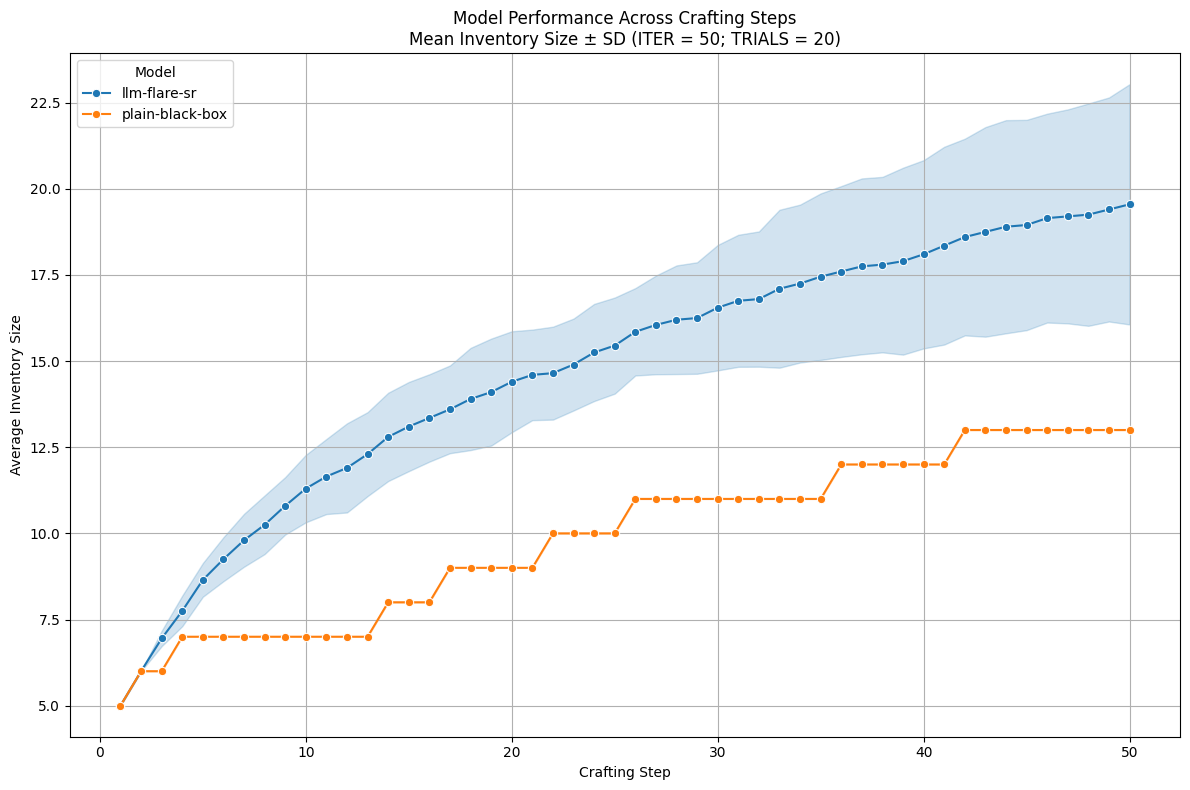

C:\Users\trakh\AppData\Local\Temp\ipykernel_42332\2041482394.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=summary.index, y=summary["mean"], palette="Set2")


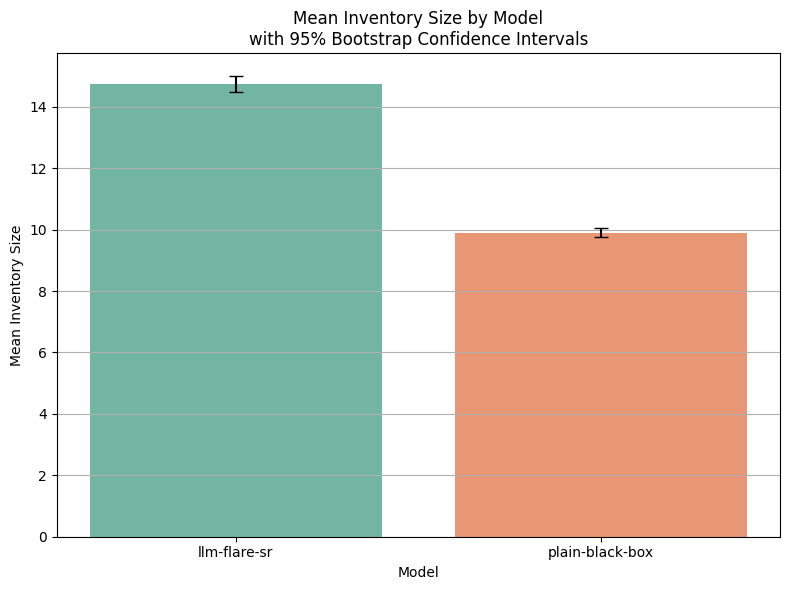

C:\Users\trakh\AppData\Local\Temp\ipykernel_42332\2041482394.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="model", y="inventory_size", palette="pastel")


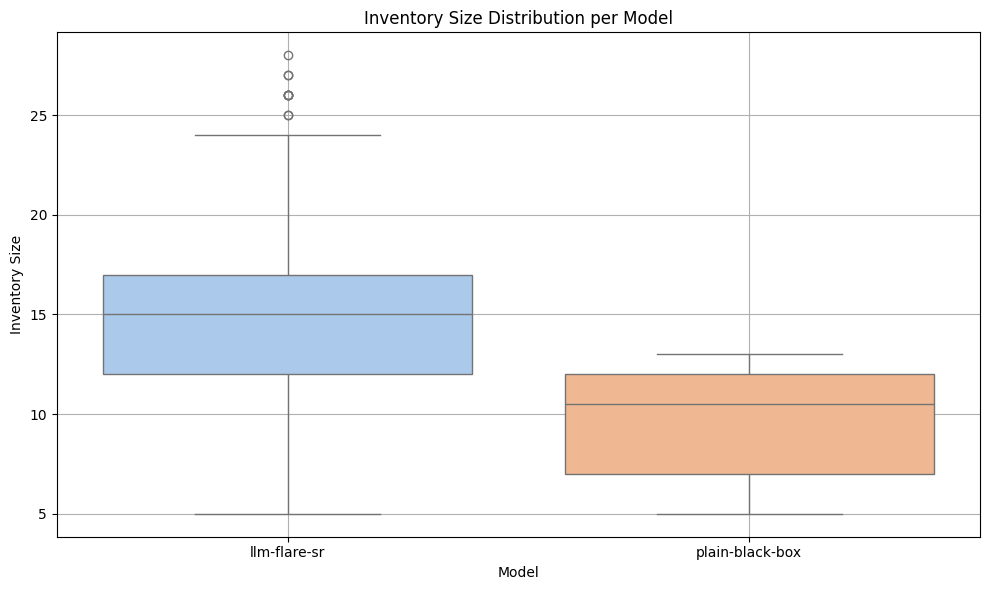

C:\Users\trakh\AppData\Local\Temp\ipykernel_42332\2041482394.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=effect_df, x="Comparison", y="Cohen_d", palette="coolwarm")


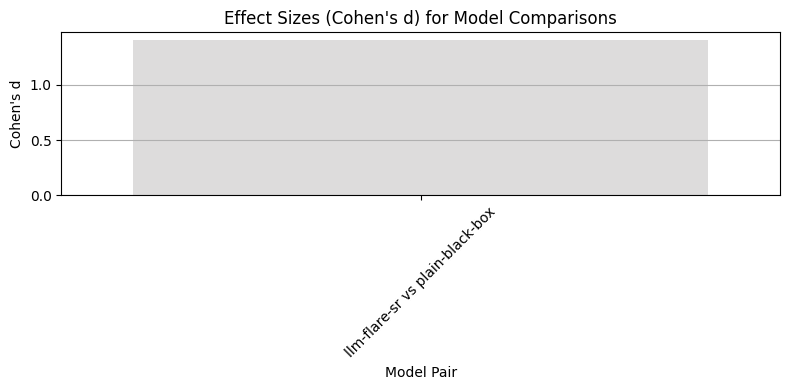

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
# from statsmodels.nonparametric.bootstrap import bootstrap
import itertools

# Assume df with columns ["model", "trial", "step", "inventory_size"] is already loaded.

# Function to compute 95% bootstrap CI for mean
def bootstrap_ci(data, n_boot=2000, alpha=0.05):
    boot_means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, n, replace=True)
        boot_means.append(np.mean(sample))
    lower = np.percentile(boot_means, 100*alpha/2)
    upper = np.percentile(boot_means, 100*(1-alpha/2))
    return lower, upper

# 1. Plot mean inventory size across steps with shaded std deviation bands
plt.figure(figsize=(12, 8))

sns.lineplot(data=df, x="step", y="inventory_size", hue="model", ci="sd", marker="o")
plt.title("Model Performance Across Crafting Steps\nMean Inventory Size ± SD (ITER = 50; TRIALS = 20)")
plt.xlabel("Crafting Step")
plt.ylabel("Average Inventory Size")
plt.legend(title="Model")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Bar plot: Mean inventory size across all trials & steps, with 95% bootstrap CI error bars
summary = df.groupby("model")["inventory_size"].agg(["mean"])
ci_bounds = {}
for model in summary.index:
    data = df[df["model"] == model]["inventory_size"].values
    ci_bounds[model] = bootstrap_ci(data)

summary["ci_lower"] = [ci_bounds[m][0] for m in summary.index]
summary["ci_upper"] = [ci_bounds[m][1] for m in summary.index]
summary["ci_err"] = summary["ci_upper"] - summary["mean"]

plt.figure(figsize=(8, 6))

# Plot bars for means only (no error bars here)
ax = sns.barplot(x=summary.index, y=summary["mean"], palette="Set2")

# Add error bars using matplotlib directly
for i, model in enumerate(summary.index):
    mean = summary.loc[model, "mean"]
    ci_low, ci_high = ci_bounds[model]
    err = [[mean - ci_low], [ci_high - mean]]
    ax.errorbar(i, mean, yerr=err, fmt='none', c='black', capsize=5, linewidth=1.5)

plt.title("Mean Inventory Size by Model\nwith 95% Bootstrap Confidence Intervals")
plt.ylabel("Mean Inventory Size")
plt.xlabel("Model")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


# 3. Box plot to show inventory size distribution per model
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="model", y="inventory_size", palette="pastel")
plt.title("Inventory Size Distribution per Model")
plt.xlabel("Model")
plt.ylabel("Inventory Size")
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Effect size plot (Cohen's d) for all pairwise model comparisons
def cohen_d(group1, group2):
    diff = abs(group1.mean() - group2.mean())
    pooled_std = np.sqrt((group1.var() + group2.var()) / 2)
    return diff / pooled_std

models = df["model"].unique()
effect_sizes = []
pairs = list(itertools.combinations(models, 2))
for m1, m2 in pairs:
    g1 = df[df["model"] == m1]["inventory_size"]
    g2 = df[df["model"] == m2]["inventory_size"]
    d = cohen_d(g1, g2)
    effect_sizes.append({"Comparison": f"{m1} vs {m2}", "Cohen_d": d})

effect_df = pd.DataFrame(effect_sizes)

plt.figure(figsize=(8, 4))
sns.barplot(data=effect_df, x="Comparison", y="Cohen_d", palette="coolwarm")
plt.title("Effect Sizes (Cohen's d) for Model Comparisons")
plt.ylabel("Cohen's d")
plt.xlabel("Model Pair")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
